# 3.1 一种无需训练权重的简单自注意力机制

## **步骤 1：** 计算未归一化的注意力分数 $\omega$

### 假设我们有如下输入句子，它已经按照第 3 章所述嵌入到 3 维向量中（为了便于说明，这里我们使用了一个非常小的嵌入维度，以便它可以完整地显示在页面上而无需换行）：

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

### (本书遵循机器学习和深度学习的常用约定，将训练样本表示为行，特征值表示为列；以上述张量为例，每一行代表一个词，每一列代表一个嵌入维度。)

In [2]:
query = inputs[1] # 第二个输入词元
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # 点积（由于它们是一维向量，因此无需转置）
print(attn_scores_2) # 第 2 个 token 的 注意力得分，点积序列

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### 附注：点积本质上是将两个向量逐元素相乘，然后将结果相加的简写形式：

In [3]:
res = 0.
for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]
print(res) # 第二个词向量 与 第一个词向量的点积
print(torch.dot(inputs[0], query)) # torch.dot 的 方法一样的

tensor(0.9544)
tensor(0.9544)


## **步骤 2：** 将未归一化的注意力得分 $\omega$ 归一化，使其总和为 1

以下是一种将未归一化的注意力分数归一化为总和为 1 的简单方法（这是一种约定俗成的做法，有利于解释，并且对训练稳定性很重要）：

In [4]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("注意力权重: ", attn_weights_2_tmp)
print("注意力分数总和: ", attn_weights_2_tmp.sum())

注意力权重:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
注意力分数总和:  tensor(1.0000)


### 然而，在实践中推荐使用 softmax 函数，因为它更擅长处理极端值，并且在训练过程中具有更理想的梯度特性。
- 以下是一个简单的 softmax 函数实现，用于缩放，它还会对向量元素进行归一化，使它们的总和为 1：

In [5]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
attn_weights_2_naive = softmax_naive(attn_scores_2)
print("注意力权重: ", attn_weights_2_naive)
print("注意力分数总和: ", attn_weights_2_naive.sum())

注意力权重:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
注意力分数总和:  tensor(1.)


- 上述简单实现方法对于过大或过小的输入值都可能由于溢出和下溢问题而出现数值不稳定问题。

### 使用 PyTorch 实现的 softmax 函数，该函数针对性能进行了高度优化：

In [6]:
attn_weights_2 = torch.softmax(attn_scores_2, dim = 0)
print("注意力权重: ", attn_weights_2)
print("注意力分数总和: ", attn_weights_2.sum())

注意力权重:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
注意力分数总和:  tensor(1.)


## **步骤 3** ：通过将嵌入的输入标记 $x^{(i)}$ 与注意力权重相乘来计算上下文向量 $z^{(2)}$，并将结果向量相加：

In [7]:
query = inputs[1] # 第二个输入词元
context_vec_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


## 3.1.1 计算所有输入词元的注意力权重

#### 将前面的步骤 1 应用于所有成对元素，以计算未归一化的注意力得分矩阵：

In [8]:
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


### 我们可以通过矩阵乘法更高效地实现上述目标：

In [9]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


#### 与之前的步骤 2 类似，我们对每一行进行归一化，使每一行的值之和为 1：

In [10]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


- 快速验证每一行中的值之和是否确实为 1：

In [11]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("第二行元素总和: ", row_2_sum)

print("全部行的各总和: ", attn_weights.sum(dim=-1))

第二行元素总和:  1.0
全部行的各总和:  tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


#### 应用之前的步骤 3 来计算所有上下文向量：

In [12]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


- #### 为了进行健全性检查，先前计算的上下文向量 $z^{(2)}=[0.4419, 0.6515, 0.5683]$ 可以在上面的第 2 行中找到：

---

# 3.2 实现具有可训练权重的自注意力机制

- ### 在 GPT 模型中，输入和输出维度通常是相同的，但为了便于说明，更好地跟踪计算过程，我们在这里选择不同的输入和输出维度：

In [13]:
x_2 = inputs[1] # 第二输入元素
d_in = inputs.shape[1] # 输入嵌入的大小，d=3
d_out = 2 # 输出嵌入大小，d=2

- #### 下面，我们初始化三个权重矩阵；请注意，为了便于说明，我们将 `requires_grad=False` 以减少输出中的冗余信息。但如果要将这些权重矩阵用于模型训练，则需要将 `requires_grad=True` 在模型训练期间更新这些矩阵。

In [14]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

- 接下来，我们计算`查询向量`、`键向量`和`值向量`：

In [15]:
query_2 = x_2 @ W_query # _2 因为它与第二个输入元素有关
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)
print(key_2)
print(value_2)

tensor([0.4306, 1.4551])
tensor([0.4433, 1.1419])
tensor([0.3951, 1.0037])


- 我们可以通过矩阵乘法获得所有键和值（将 6 个输入词元从 3D 空间投影到 2D 嵌入空间）:

In [16]:
keys = inputs @ W_key
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


## **步骤 1**：计算查询向量与每个键向量之间的 `点积` 来计算未归一化的`注意力得分`： 

- 首先，让我们计算未归一化的注意力得分$w_{22}$

In [17]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


- 同样，我们可以通过矩阵乘法将此计算推广到所有注意力得分$w$：

In [18]:
attn_scores_2 = query_2 @ keys.T # 给定查询的所有注意力得分
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


## **步骤 2**：我们使用之前用过的 softmax 函数计算 `注意力权重`（归一化的注意力得分之和为 1）。

- 与之前不同的是，我们现在通过将 `注意力得分` 除以嵌入维度的平方根 $\sqrt{d_k}$ 即 （`d_k**0.5` ）来缩放`注意力得分`：

In [19]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


## **步骤 3**：计算输入查询向量 2 的`上下文向量`：

In [20]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


## 3.2.2 实现一个简洁的 SelfAttention 类

In [21]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_vl = SelfAttention_v1(d_in, d_out)
print(sa_vl(inputs)) # 生成一个存储六个上下文向量的矩阵

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


- 快速检查一下，注意第二行 ([0.3061, 0.8210]) 与上一节中的context_vec_2 内容匹配。

## 3.2.3 使用 PyTorch 线性层的自注意力类

In [22]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


---

## 3.3.1 应用因果注意力掩码

### 方法一：

- 为了说明和实现因果自注意力机制，让我们使用上一节中的注意力分数和权重：

In [23]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


- 屏蔽未来注意力权重的最简单方法是使用 PyTorch 的 `tril` 函数。
- `tril` 会创建一个掩码，将主对角线下方的元素（包括对角线本身）设置为 1，将主对角线上方的元素设置为 0：

In [24]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


- 然后，我们可以将注意力权重与该掩码相乘，使对角线以上的注意力得分归零：

In [25]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


- 重新归一化注意力权重，使每行的和再次为1。
- 我们可以通过将每行中的每个元素除以该行的总和来实现这一点：

In [26]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


## 但是注意！
- ### 如果像上面那样在 softmax 之后应用掩码，就会破坏 softmax 生成的概率分布。
- ### 在 softmax 之后进行掩蔽操作需要重新归一化输出，使其总和再次为 1，这会使过程复杂化，并可能导致意想不到的效果。

### 让我们简要地看一下实现上述相同功能的更高效方法:

### 方法二：
- 因此，与其将对角线以上的注意力权重置零并重新归一化结果，我们可以在未归一化的注意力得分进入 softmax 函数之前，用负无穷大掩盖对角线以上的未归一化注意力得分：

In [27]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


- 如下所示，现在每一行的注意力权重之和又正确地为 1：

In [28]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


## 3.3.2 使用 dropout 掩盖额外的注意力权重

- ### 这里，我们将在计算注意力权重之后应用 dropout 掩码，因为这样做更常见。

在这个具体例子中，我们使用了 50% 的 dropout 率，这意味着随机丢弃一半的注意力权重。（之后训练 GPT 模型时，我们会使用更低的 dropout 率，例如 0.1 或 0.2）。

In [29]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # Dropout 的丢弃率为 50%
example = torch.ones(6, 6) # 创建一个 元素都为 1 的张量
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [30]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


## 3.3.3 实现紧凑型因果注意力类

- 现在，我们已准备好实现一个可用的自注意力机制，包括因果掩码和 dropout 掩码。
- 还有一点需要实现，即编写代码来处理包含多个输入的批次，以便我们的 `CausalAttention` 类能够支持我们在第二章中实现的数据加载器生成的批次输出。

In [31]:
batch = torch.stack((inputs, inputs), dim=0) # 将维度完全相同的张量进行拼接
print(batch.shape) # 2 个输入张量，每个包含 6 个词元; 每个词元的嵌入深度为 3 

torch.Size([2, 6, 3])


In [32]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # 新的 d-dimension
        # 对于 `num_tokens` 超过 `context_length` 的输入，这将导致错误
        # 在后面的掩码创建过程中。
        # 实际上，这不是问题，因为 LLM（第 4-7 章）确保输入
        # 在到达此前向方法之前不会超过 `context_length`。
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # 变化转置
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` 用于处理批次中的 token 数量小于支持的 context_size 的情况。
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec
torch.manual_seed(123)

context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


---

# 3.4 将单头注意力扩展到多头注意力

## 3.4.1 堆叠多个单头注意力层
- 多头注意力机制的核心思想是使用不同的、已学习的线性投影（即输入数据（例如注意力机制中的查询向量、键向量和值向量）乘以权重矩阵的结果）多次（并行地）运行注意力机制。

In [40]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)

context_length = batch.shape[1] # 这是词元数量
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


- #### 生成的 context_vecs 张量的第一维为 2，因为我们有两个输入文本（输入文本是重复的，所以它们的上下文向量完全相同）。
- #### 第二维指的是每个输入中的 6 个词元。
- #### 第三维指的是每个词元的四维嵌入。

## 3.4.2 通过权重拆分实现多头注意力

- 对于这个独立的 MultiHeadAttention 类，我们不会将单个注意力头连接起来。
- 相反，我们创建单个 W_query、W_key 和 W_value 权重矩阵，然后将它们拆分为每个注意力头的单独矩阵：

In [42]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # As in `CausalAttention`, for inputs where `num_tokens` exceeds `context_length`, 
        # this will result in errors in the mask creation further below. 
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs  
        # do not exceed `context_length` before reaching this forward method.

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


- 请注意，以上内容本质上是 MultiHeadAttentionWrapper 的重写版本，效率更高。

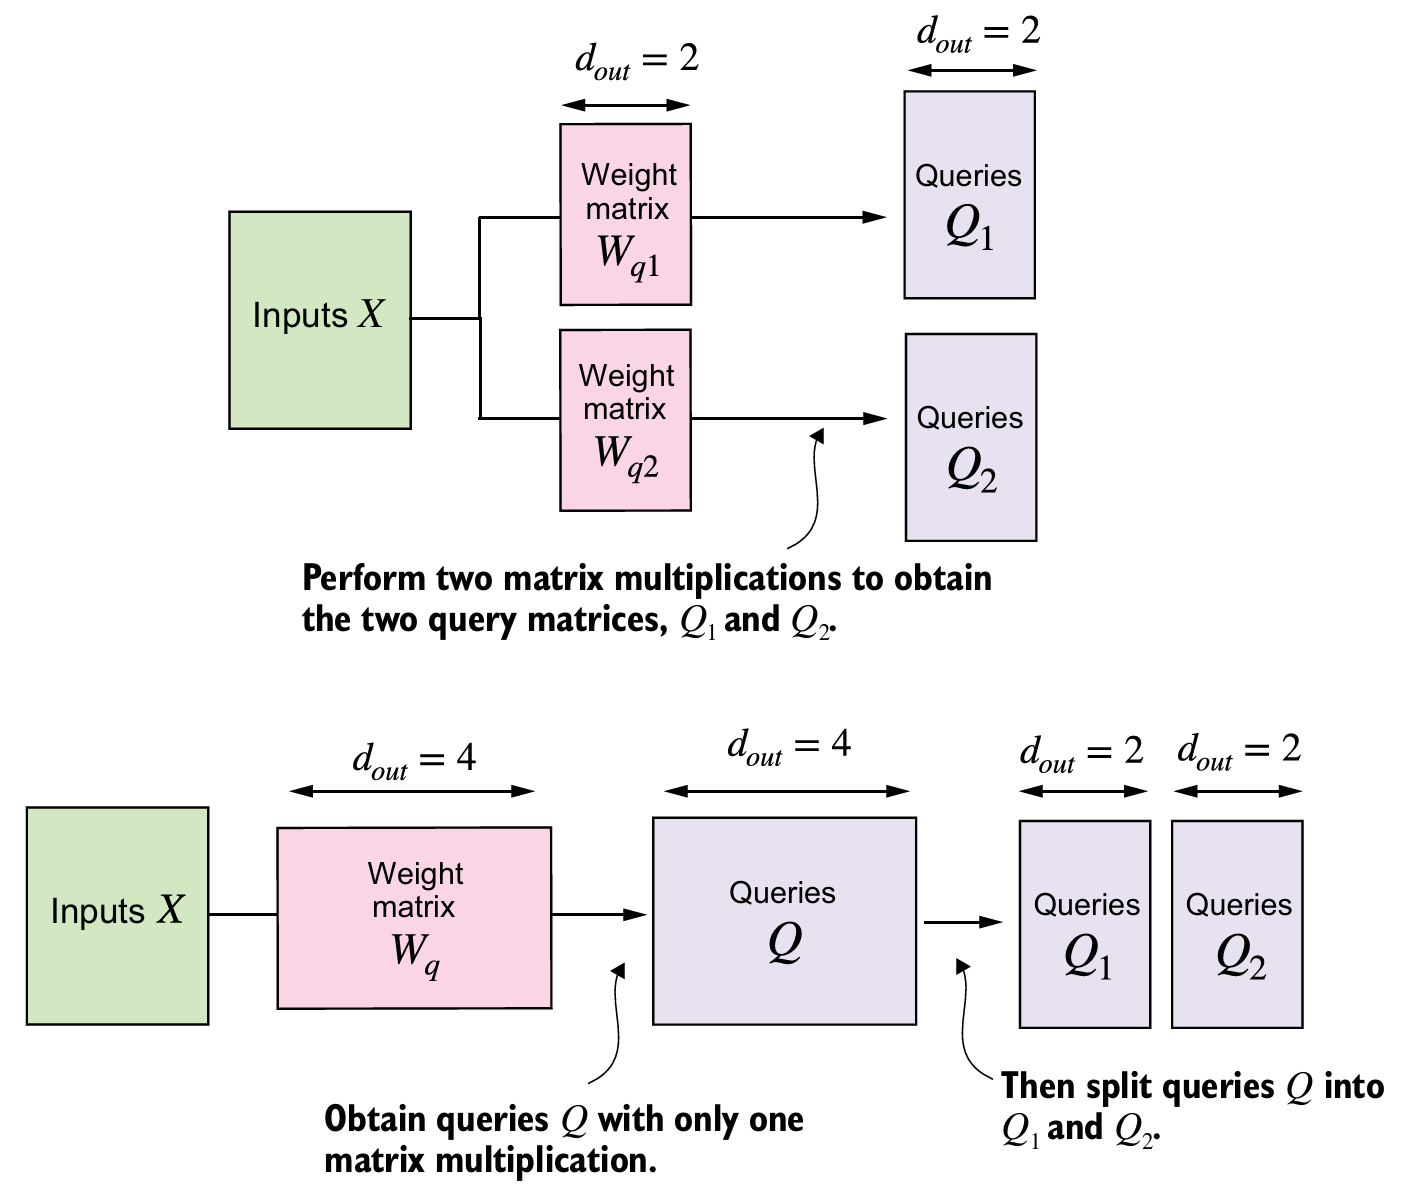